In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data
from scipy import misc

In [3]:
def img_details(name,img):
    plt.imshow(img)
    plt.title(f"{name} {img.shape}")
    #plt.axis('off')
    plt.show()

In [4]:
def subplot(name,img,shape,i):
    plt.subplot(shape[0],shape[1],i)
    plt.imshow(img)
    plt.title(f'{name}')

**READ THE IMAGE**

C:\Users\sanka\AppData\Local\Temp\ipykernel_17056\702292235.py:3: DeprecationWarning: scipy.misc.face has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.face instead.
  img3 = misc.face()


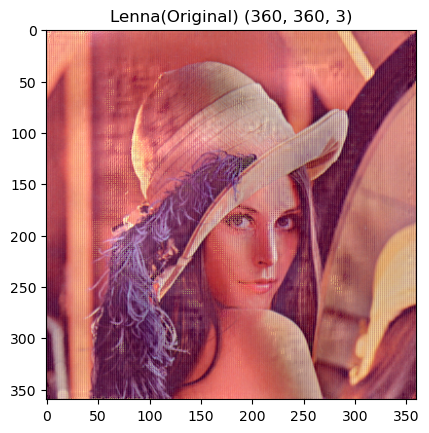

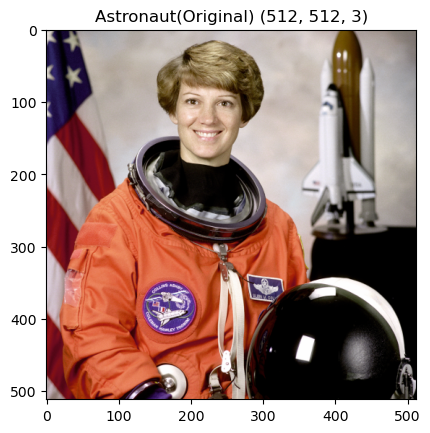

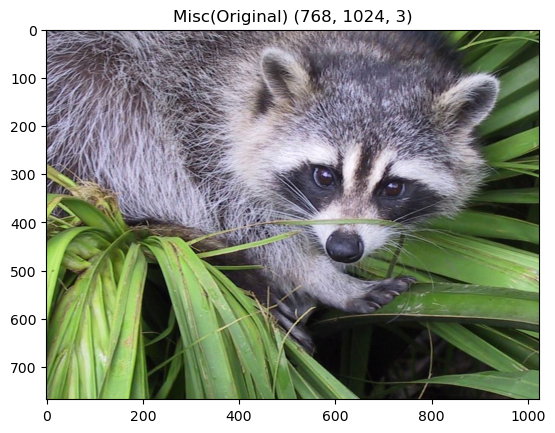

In [7]:
img1 = plt.imread(r"C:\Users\sanka\Downloads\Lena.png")
img2 = data.astronaut()
img3 = misc.face()

img_details('Lenna(Original)',img1)
img_details('Astronaut(Original)',img2)
img_details('Misc(Original)',img3)

# TRANSFORMATIONS

**TRANSLATION**

In [8]:
#Using In built function
def translation(img,ax=0,ay=0,tx=100,ty=50):
    h,w = img.shape[:2]
    T = np.float32([ [1,0,tx],[0,1,ty]] )
    translated_img = cv2.warpAffine(img,T,(w+ax,h+ay))

    return translated_img

In [9]:
#Using User defined function
def _translation(img,ax=0,ay=0,tx=100,ty=50):
    h,w = img.shape[:2]
    #T = np.float32([ [1,0,tx],[0,1,ty]] )
    
    translated_img = np.zeros(shape=(h+ay,w+ax,3),dtype=img.dtype)
    for y in range(h):
        for x in range(w):
            new_x = x+tx
            new_y = y+ty

            if 0<=new_x<(w+ax) and 0<=new_y<(h+ay):
                translated_img[new_y,new_x] = img[y,x]

    return translated_img

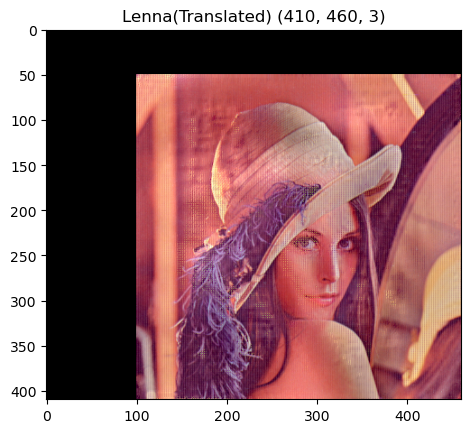

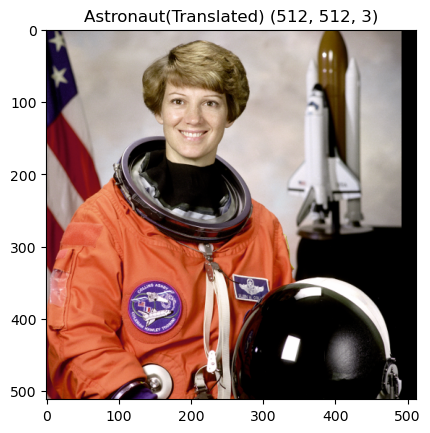

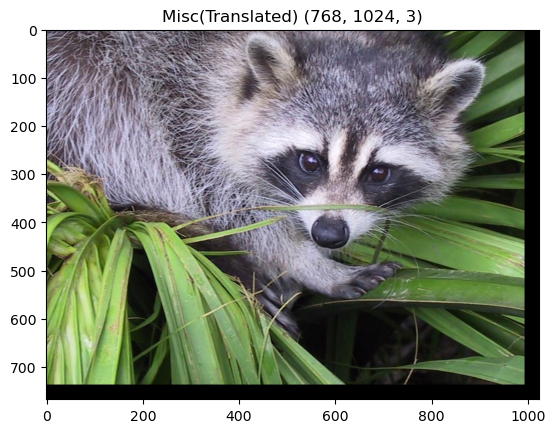

In [10]:
img_details('Lenna(Translated)',_translation(img1,ax=100,ay=50))
img_details('Astronaut(Translated)',translation(img2,tx=-20,ty=0))
img_details('Misc(Translated)',_translation(img3,tx=-30,ty=-30))

**ROTATION**

In [11]:
#Using In built function
def rotation(img, angle,point=None):

    angle = angle*-1
    h, w = img.shape[:2]
    if point == None:
        point = (w//2,h//2)
        
    M = cv2.getRotationMatrix2D(point, angle, 1)
    rotated_img = cv2.warpAffine(img, M, (w, h))
    
    return rotated_img

In [12]:
#Using User defined function
def _rotation(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    rad = np.deg2rad(angle)

    M = np.array([
        [np.cos(rad), -np.sin(rad), center[0] - center[0] * np.cos(rad) + center[1] * np.sin(rad)],
        [np.sin(rad), np.cos(rad), center[1] - center[0] * np.sin(rad) - center[1] * np.cos(rad)],
        [0,0,1]
    ], dtype=np.float32)

    M_inv = np.linalg.inv(M)
    
    rotated_img = np.zeros_like(img)

    for y_new in range(h):
        for x_new in range(w):
            arr = np.array([[x_new], [y_new], [1]])
            old_coords = M_inv @ arr

            x_old = int(old_coords[0])
            y_old = int(old_coords[1])

            if 0 <= x_old < w and 0 <= y_old < h:
                rotated_img[y_new, x_new] = img[y_old, x_old]

    return rotated_img


C:\Users\sanka\AppData\Local\Temp\ipykernel_17056\136939030.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_old = int(old_coords[0])
C:\Users\sanka\AppData\Local\Temp\ipykernel_17056\136939030.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_old = int(old_coords[1])


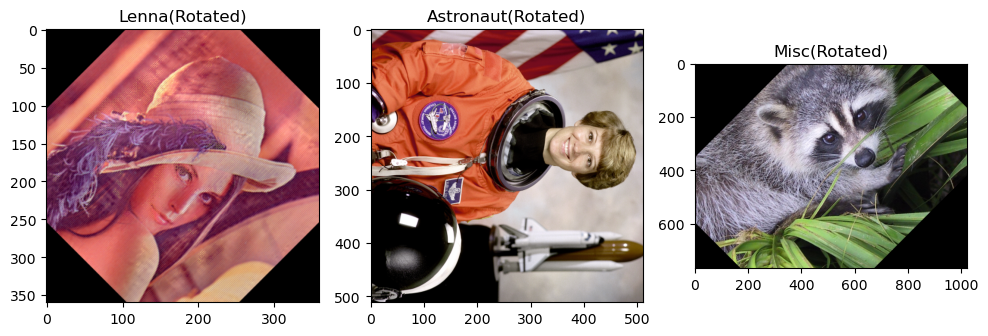

In [13]:
plt.figure(figsize=(10,10))
subplot(f'Lenna(Rotated)', rotation(img1, 45) , (1,3) , 1 )
subplot('Astronaut(Rotated)', _rotation(img2, 90) , (1,3) , 2)  
subplot('Misc(Rotated)', _rotation(img3, -45) , (1,3) , 3)
plt.tight_layout()
plt.show()

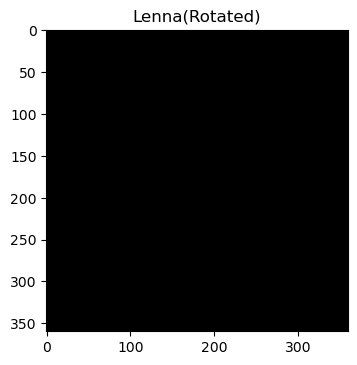

In [14]:
plt.figure(figsize=(10,10))
subplot(f'Lenna(Rotated)', rotation(img1, 230,point=(0,0)) , (1,3) , 1 )
plt.tight_layout()
plt.show()

**SCALING**

In [15]:
def _scaling(img, scale_factor):
    h, w = img.shape[:2]
    new_h, new_w = int(h * scale_factor), int(w * scale_factor)
    
    scaled_img = np.zeros_like(img)
    start_x = (w - new_w) // 2
    start_y = (h - new_h) // 2
    
    for y_new in range(new_h):
        for x_new in range(new_w):
            x_old = int(x_new / scale_factor)
            y_old = int(y_new / scale_factor)
            
            if 0 <= x_old < w and 0 <= y_old < h and 0 <= start_x + x_new < w and 0 <= start_y + y_new < h:
                scaled_img[start_y + y_new, start_x + x_new] = img[y_old, x_old]
    
    return scaled_img

In [16]:
def scaling(img, scale_factor):
    h, w = img.shape[:2]
    new_h, new_w = int(h * scale_factor), int(w * scale_factor)
    
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    scaled_img = np.zeros_like(img)
    start_x = (w - new_w) // 2
    start_y = (h - new_h) // 2
    scaled_img[start_y:start_y + new_h, start_x:start_x + new_w] = resized
    
    return scaled_img

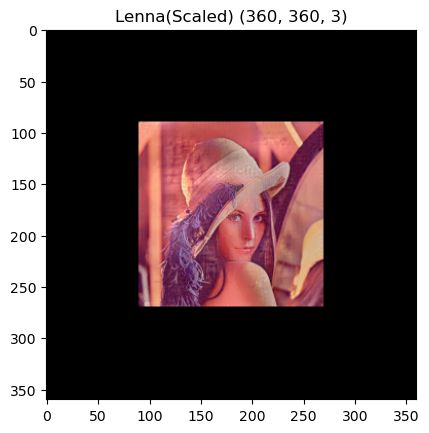

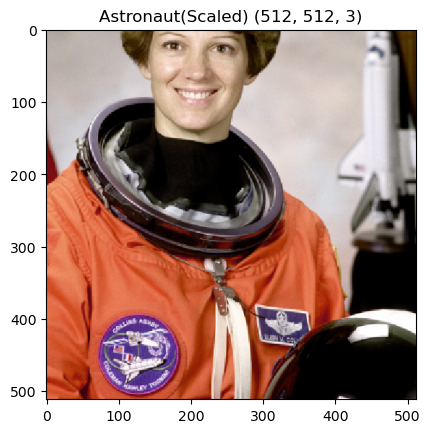

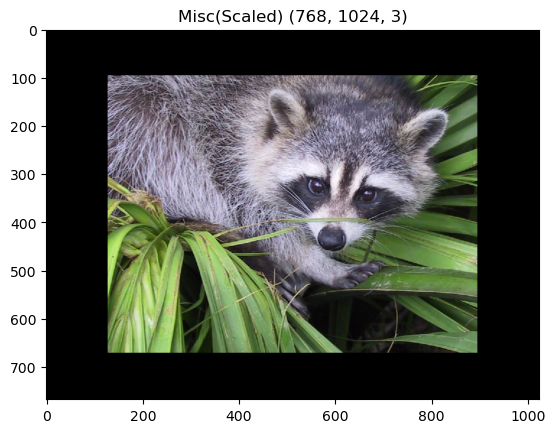

In [21]:
img_details('Lenna(Scaled)', scaling(img1, 0.5))  
img_details('Astronaut(Scaled)', _scaling(img2, 1.5)) 
img_details('Misc(Scaled)', _scaling(img3, 0.75)) 

**SHEARING**

In [13]:
def _shearing(img, shear_factor_x, shear_factor_y):
    h, w = img.shape[:2]
    
    # Shear transformation matrix (3x3)
    M = np.array([
        [1, shear_factor_x, 0], 
        [shear_factor_y, 1, 0],
        [0, 0, 1]
    ])
    
    M_inv = np.linalg.inv(M)  # Inverse for backward mapping
    
    # Create a black canvas of the same size
    sheared_img = np.zeros_like(img)
    
    for y_new in range(h):
        for x_new in range(w):
            old_coords = M_inv @ np.array([[x_new], [y_new], [1]])
            x_old, y_old = int(old_coords[0]), int(old_coords[1])

            if 0 <= x_old < w and 0 <= y_old < h:
                sheared_img[y_new, x_new] = img[y_old, x_old]
    
    return sheared_img

In [14]:
def shearing(img, shear_factor_x, shear_factor_y):
    h, w = img.shape[:2]
    
    # Shear transformation matrix (2x3)
    M = np.array([
        [1, shear_factor_x, 0], 
        [shear_factor_y, 1, 0]
    ])
    
    sheared_img = cv2.warpAffine(img, M, (w, h))
    
    return sheared_img

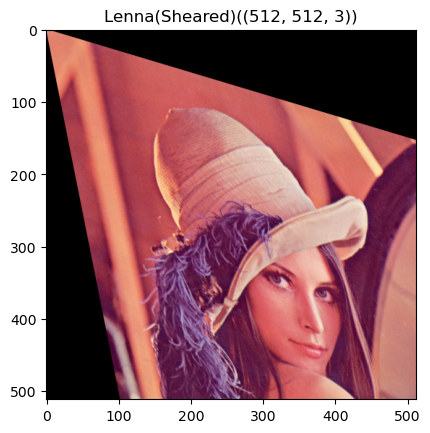

C:\Users\student\AppData\Local\Temp\ipykernel_8812\3952299217.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_old, y_old = int(old_coords[0]), int(old_coords[1])


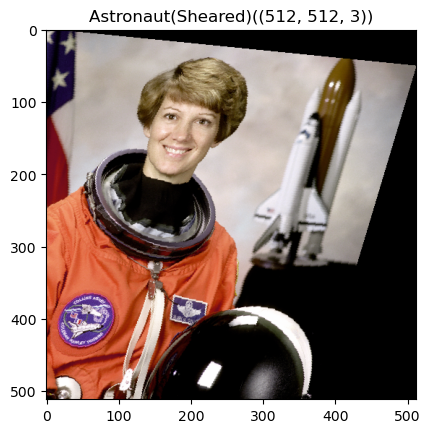

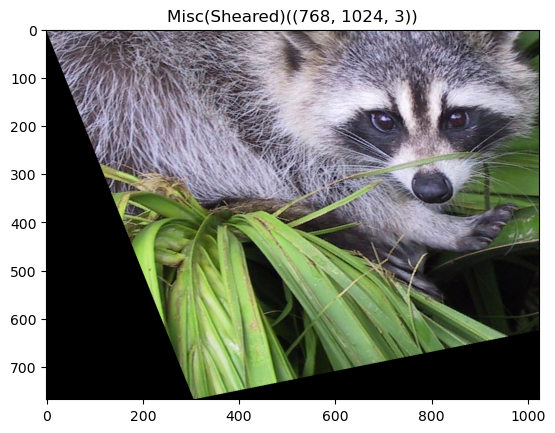

In [15]:
# Apply shearing to images
img_details('Lenna(Sheared)', shearing(img1, 0.2, 0.3))  
img_details('Astronaut(Sheared)', _shearing(img2, -0.3, 0.1)) 
img_details('Misc(Sheared)', _shearing(img3, 0.4, -0.2)) 

**REFLECTION**

In [16]:
def _reflection(img, axis):
    h, w = img.shape[:2]
    
    # Reflection transformation matrix
    if axis == 'x':  # Reflect across the x-axis (flip vertically)
        M = np.array([
            [1, 0, 0], 
            [0, -1, h - 1]
        ], dtype=np.float32)
    elif axis == 'y':  # Reflect across the y-axis (flip horizontally)
        M = np.array([
            [-1, 0, w - 1], 
            [0, 1, 0]
        ], dtype=np.float32)
    else:  # No reflection if invalid axis
        return img

    # Apply transformation manually
    h, w = img.shape[:2]
    reflected_img = np.zeros_like(img)

    for y_new in range(h):
        for x_new in range(w):
            old_coords = np.matmul(M, np.array([x_new, y_new, 1], dtype=np.float32))
            x_old, y_old = int(old_coords[0]), int(old_coords[1])

            if 0 <= x_old < w and 0 <= y_old < h:
                reflected_img[y_new, x_new] = img[y_old, x_old]
    
    return reflected_img

In [17]:
def reflection(img, axis):
    h, w = img.shape[:2]
    
    if axis == 'x':  # Reflect across x-axis (flip vertically)
        M = np.array([
            [1, 0, 0], 
            [0, -1, h - 1]
        ], dtype=np.float32)
    elif axis == 'y':  # Reflect across y-axis (flip horizontally)
        M = np.array([
            [-1, 0, w - 1], 
            [0, 1, 0]
        ], dtype=np.float32)
    else:  # No reflection if invalid axis
        return img

    # Use OpenCV's warpAffine
    reflected_img = cv2.warpAffine(img, M, (w, h))
    
    return reflected_img

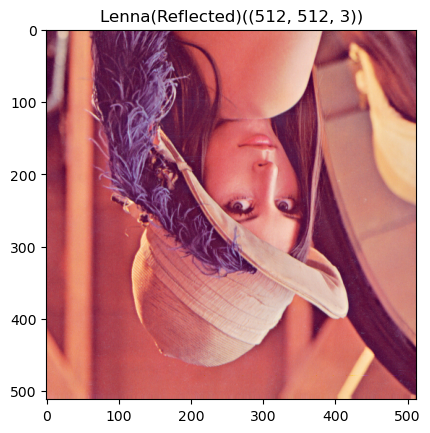

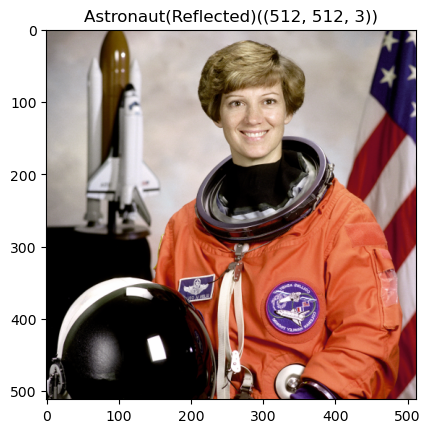

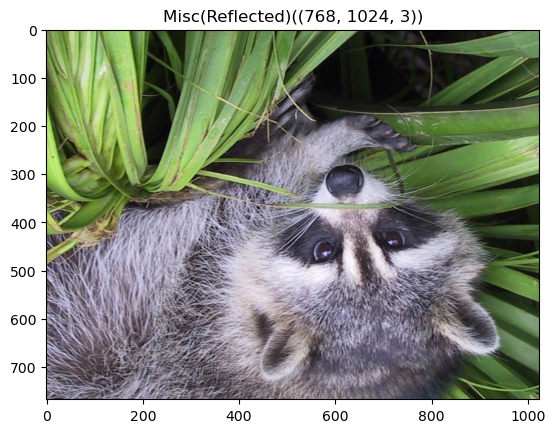

In [18]:
# Apply reflection to images
img_details('Lenna(Reflected)', reflection(img1, 'x'))  
img_details('Astronaut(Reflected)', _reflection(img2, 'y')) 
img_details('Misc(Reflected)', _reflection(img3, 'x')) 

**AFFINE TRANSFORM**

In [19]:
def _combined_transform(img, angle, scale_x, scale_y, shear_x, shear_y, reflect_x, reflect_y, translate_x, translate_y):
    h, w = img.shape[:2]
    rad = np.deg2rad(angle)
    
    M = np.array([
        [scale_x * (np.cos(rad) + shear_x * np.sin(rad)) * (-1 if reflect_y else 1), 
         -scale_y * (np.sin(rad) - shear_x * np.cos(rad)) * (-1 if reflect_x else 1), 
         translate_x],
        [scale_x * (np.sin(rad) + shear_y * np.cos(rad)) * (-1 if reflect_y else 1), 
         scale_y * (np.cos(rad) + shear_y * np.sin(rad)) * (-1 if reflect_x else 1), 
         translate_y],
        [0, 0, 1]
    ])
    
    M_inv = np.linalg.inv(M)
    
    transformed_img = np.zeros_like(img)
    
    for y_new in range(h):
        for x_new in range(w):
            old_coords = M_inv @ np.array([x_new, y_new, 1])
            x_old, y_old = int(old_coords[0]), int(old_coords[1])

            if 0 <= x_old < w and 0 <= y_old < h:
                transformed_img[y_new, x_new] = img[y_old, x_old]
    
    return transformed_img

In [59]:
def combined_transform(img, angle, scale_x, scale_y, shear_x, shear_y, reflect_x, reflect_y, translate_x, translate_y):
    h, w = img.shape[:2]
    rad = np.deg2rad(angle)
    
    # Reflection on X axis only if reflect_x is True
    reflect_x_factor = -1 if reflect_x else 1
    reflect_y_factor = -1 if reflect_y else 1

    # Check if both shear values are zero
    if shear_x == 0 and shear_y == 0:
        # No shear, just apply scaling, rotation, reflection, and translation
        M = np.array([
            [scale_x * np.cos(rad) * reflect_x_factor, -scale_y * np.sin(rad), translate_x],
            [scale_x * np.sin(rad), scale_y * np.cos(rad) * reflect_y_factor, translate_y]
        ], dtype=np.float32)
    else:
        # Apply shear terms if they are non-zero
        M = np.array([
            [scale_x * (np.cos(rad) + shear_x * np.sin(rad)) * reflect_x_factor, 
             -scale_y * (np.sin(rad) - shear_x * np.cos(rad)), 
             translate_x],
            [scale_x * (np.sin(rad) + shear_y * np.cos(rad)), 
             scale_y * (np.cos(rad) + shear_y * np.sin(rad)) * reflect_y_factor, 
             translate_y]
        ], dtype=np.float32)

    # Calculate new bounds for the transformed image to avoid clipping
    corners = np.array([
        [0, 0], [w-1, 0], [w-1, h-1], [0, h-1]  # Coordinates of the 4 corners
    ])
    transformed_corners = cv2.transform(np.float32([corners]), M).reshape(-1, 2)

    # Find new bounds for the transformed image
    min_x, min_y = transformed_corners.min(axis=0)
    max_x, max_y = transformed_corners.max(axis=0)

    # Calculate the size of the new image
    new_w = int(np.ceil(max_x - min_x))
    new_h = int(np.ceil(max_y - min_y))

    # Adjust the translation to keep the image within the new canvas
    translation_x = -min_x
    translation_y = -min_y

    # Adjust the transformation matrix with the new translation
    M[0, 2] += translation_x
    M[1, 2] += translation_y

    # Perform the affine transformation
    transformed_img = cv2.warpAffine(img, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    
    return transformed_img


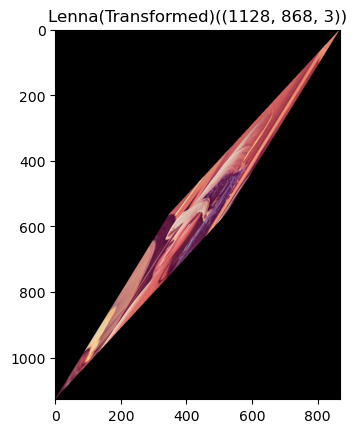

In [62]:
img_details('Lenna(Transformed)', combined_transform(img1, 45, 1.2, 1.2, 0.2, 0.3, 1, 0, 50, 50))  

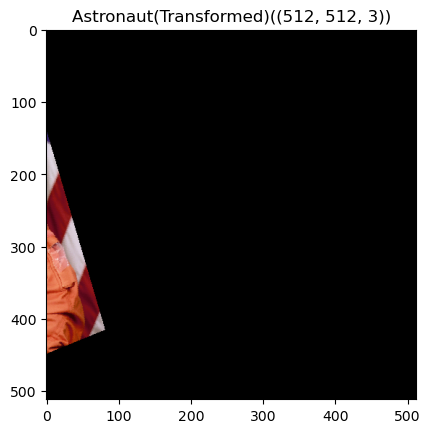

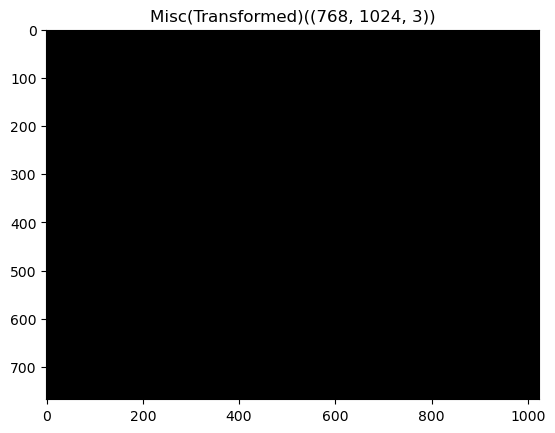

In [61]:
img_details('Astronaut(Transformed)', _combined_transform(img2, -30, 0.8, 0.9, -0.3, 0.1, 0, 1, -30, 40)) 
img_details('Misc(Transformed)', _combined_transform(img3, 60, 1.5, 1.5, 0.4, -0.2, 1, 1, 20, -20))  